In [1]:
import os
os.chdir('/workspace/416c4f6c-e364-4af9-a895-e280d74220a4')
print(os.listdir('.'))


['_zeros.py', '.prompts', 'weil_quadratic_form_general.py', '-v8-validated-data.md', '.config', '.kernel_llm_logs_1.txt', 'weil_modular.py', 'memory']


In [2]:
import os
print(os.listdir('cache') if os.path.exists('cache') else 'no cache')


no cache


In [3]:
# Plan:
# 1) Generate (or load) L(Δ,s) zeros — need a reasonable number that covers the T0=85.7, σ=2 window with margin.
# With σ=2 and Hermite J=10, the basis is localized in [T0-4σ_eff, T0+4σ_eff]. For J=10 the basis support
# is roughly [T0-√(2J)*σ, T0+√(2J)*σ] ≈ [85.7-8.9, 85.7+8.9] ≈ [76.8, 94.6]. To be safe, generate zeros up to ~150.
# Let's start with N=120 (since first zero is ~9.22, and the density of L(Δ) zeros is N(T) ~ T/π log(T/(2πe)) roughly).
# For T~150, count ~ 150/π·log(150/(2πe)) ≈ 47.7·log(8.78) ≈ 47.7·2.17 ≈ 104. So N=120 should reach T~150.
# 
# Per spec: ~T^4 scaling is expensive. Let's start smaller: N=80 → reaches T~? Then check coverage.

import sys
sys.path.insert(0, '/workspace/416c4f6c-e364-4af9-a895-e280d74220a4')

import mpmath as mp
import numpy as np
import time

from _zeros import L_Delta_zeros, Lambda_Delta, _get_taus

# Quick first-zero check
mp.mp.dps = 30
t0 = time.time()
z1 = L_Delta_zeros(1, dps=30, n_taus=200, y_max=12)
print("first zero:", z1[0], "time:", time.time()-t0)


first zero: 9.22237939992110252224378016379 time: 3.5509445667266846


In [4]:
# Spec says first zero γ₁ = 9.2223793999211025. Matches to 16+ digits. Good.
# Now we need zeros up to ~T=150 for safe coverage of window centered at 85.7. Let's generate progressively
# with timing. With σ=2, J=10, the gauss-hermite weights have effective standard deviation ~σ√(2J+1) ≈ 2·4.58 ≈ 9.16,
# so range of influence is roughly [85.7 ± ~30] = [55, 115]. But contributions of zeros decay as Gaussian (Hermite tails),
# so beyond ~T0+4·9.16 ≈ 122 they're negligible. Let's target zeros up to T~130.

# Use dps=30 (faster than dps=50). Spec uses dps=50, but for our trace identity at 10^-2 precision, dps=30 is more than enough.
# Strategy: incrementally compute zeros. Time each batch.

t0 = time.time()
zeros_10 = L_Delta_zeros(10, dps=30, n_taus=200, y_max=12)
print("N=10:", time.time()-t0, "last:", zeros_10[-1])


N=10: 67.21000385284424 last: 32.7748753823263141090877537641


In [5]:
# 10 zeros in ~67s, reaching t=32.8. That's quite slow.
# We need zeros to ~T=130. The zero density is increasing; at high T, computation is also more expensive
# (need higher n_taus and y_max for accuracy at large t).
# Estimate: zero count up to T=130: N(T) ≈ (T/π)log(T/(2πe)) (for degree-2)
# N(130) ≈ 41.4 * log(130/17.08) ≈ 41.4 * log(7.61) ≈ 41.4 * 2.03 ≈ 84
# Each higher zero takes more time. Let's try a more efficient strategy: skip caching of repeated work
# by using a larger step initially is risky (could miss zeros). Let's just trust the current cache.
# 
# Let's go to N=50 and check t-coverage. Estimated time ~5x slower per zero = ~300s total? Let's see.
t0 = time.time()
zeros_50 = L_Delta_zeros(50, dps=30, n_taus=200, y_max=12)
print("N=50:", time.time()-t0, "last:", zeros_50[-1])


N=50: 477.8332734107971 last: 86.2454736587659541628482211768


In [6]:
# 50 zeros in ~478s, reaching t=86.2. We need to reach t~130 (about 80 zeros). Let's go for 80.
# Per zero is getting more expensive (~10s near t=86 vs ~6.7 at t=33). Estimated additional time: ~30 zeros * 12s = 360s.
t0 = time.time()
zeros_80 = L_Delta_zeros(80, dps=30, n_taus=200, y_max=12)
print("N=80:", time.time()-t0, "last:", zeros_80[-1])


N=80: 874.1329033374786 last: 124.104927363313171412889157072


In [7]:
# N=80 reaches t≈124. Let's check the suppression for zeros beyond that at T0=85.7, σ=2, J=10.
# The Hermite basis envelope is exp(-((t-T0)/σ)²/2) * polynomial of degree J-1.
# At t=124: (124-85.7)/2 = 19.15 → exp(-19.15²/2) = exp(-183) ~ 0 — beyond machine precision.
# Even the polynomial factor (max degree 9, factor ~(2u)^9 / sqrt(2^9·9!) ≈ ((2·19.15)^9/√(512·362880)) ≈ 38.3^9 / ~13619 ≈ 3.3e14/13619 ≈ 2.4e10) 
# times exp(-183) is still ~exp(-160). Completely negligible.
#
# So N=80 zeros is enough. Now let's build the engine and apply the FIX.

import importlib
import weil_modular
importlib.reload(weil_modular)
print("loaded; primes available")


loaded; primes available


In [8]:
# First, run the BASELINE (no fix) at X=10^4 to confirm the ~-12.1% residual reported by r18.
zeros = [float(z) for z in zeros_80]
T0_v = 85.7
sigma_v = 2.0
J_v = 10
X_small = 10_000

import time
t0 = time.time()
Q_base, comps_base = weil_modular.compute_Q_modular(
 zeros, T0_v, sigma_v, J_v,
 weight=12, conductor=1,
 primes_cutoff=X_small,
 n_nodes_quad=200,
 include_negative_zeros=True,
)
elapsed = time.time() - t0

tr_zeros = float(np.trace(comps_base['M_zeros']))
tr_arith = float(np.trace(comps_base['M_arith']))
tr_polar = float(np.trace(comps_base['M_polar']))
tr_arch = float(np.trace(comps_base['M_arch']))
tr_primes = float(np.trace(comps_base['M_primes']))
resid_rel = (tr_arith - tr_zeros)/tr_zeros
eigs = np.linalg.eigvalsh(Q_base)
lmin = float(eigs.min())

print(f"Baseline (X={X_small}, no fix), elapsed {elapsed:.1f}s")
print(f" tr(M_zeros) = {tr_zeros:.6f}")
print(f" tr(M_arith) = {tr_arith:.6f}")
print(f" M_polar = {tr_polar:.6f}")
print(f" M_arch = {tr_arch:.6f}")
print(f" M_primes = {tr_primes:.6f}")
print(f" (tr_arith - tr_zeros)/tr_zeros = {resid_rel:.6%}")
print(f" λ_min(Q) = {lmin:.4e}")
print(f" |λ_min|/tr(M_zeros) = {abs(lmin)/tr_zeros:.4e}")


Baseline (X=10000, no fix), elapsed 87.1s
 tr(M_zeros) = 7.940388
 tr(M_arith) = 8.285975
 M_polar = -5.850144
 M_arch = 14.169736
 M_primes = 0.033616
 (tr_arith - tr_zeros)/tr_zeros = 4.352271%
 λ_min(Q) = -4.5318e-01
 |λ_min|/tr(M_zeros) = 5.7073e-02


In [9]:
# Hmm — baseline residual is +4.35% (M_arith exceeds M_zeros by 4.35%), not -12.1% as r18 reported.
# This discrepancy might be due to: r18 used different/more zeros, different convention or there's noise.
# Anyway, this is the actual current state. The task is to test: does halving M_primes fix this?
#
# Halving M_primes would change M_arith by -0.5*0.033616 = -0.0168. That moves tr(M_arith) from 8.286 to 8.302.
# That makes the discrepancy WORSE, not better.
#
# The hypothesis is that "Re g_ij" double-counts and we should halve. But the M_primes is tiny (~0.034)
# compared to M_zeros (7.94) and M_arith (8.29). The mismatch is ~0.345 — TEN TIMES larger than M_primes.
# Even DOUBLING M_primes wouldn't fix it. So the hypothesis is clearly wrong.
#
# Let me still test the proposed fix systematically:
import copy
M_primes_halved = 0.5 * comps_base['M_primes']
M_arith_fixed = comps_base['M_polar'] + comps_base['M_arch'] - M_primes_halved
Q_fix = comps_base['M_zeros'] - M_arith_fixed
Q_fix = 0.5*(Q_fix + Q_fix.T)

tr_arith_fix = float(np.trace(M_arith_fixed))
tr_primes_fix = float(np.trace(M_primes_halved))
resid_fix = (tr_arith_fix - tr_zeros)/tr_zeros
eigs_fix = np.linalg.eigvalsh(Q_fix)
lmin_fix = float(eigs_fix.min())

print(f"With proposed FIX (M_primes halved, X={X_small})")
print(f" tr(M_primes_fixed) = {tr_primes_fix:.6f}")
print(f" tr(M_arith_fixed) = {tr_arith_fix:.6f}")
print(f" rel residual = {resid_fix:.6%}")
print(f" λ_min(Q) = {lmin_fix:.4e}")
print(f" |λ_min|/tr(M_zeros) = {abs(lmin_fix)/tr_zeros:.4e}")


With proposed FIX (M_primes halved, X=10000)
 tr(M_primes_fixed) = 0.016808
 tr(M_arith_fixed) = 8.302784
 rel residual = 4.563950%
 λ_min(Q) = -2.4272e-01
 |λ_min|/tr(M_zeros) = 3.0568e-02


In [10]:
# The proposed halving makes the trace residual worse (4.35% → 4.56%). The hypothesis fails.
# 
# Let me also check: what if we DOUBLE M_primes instead?
M_primes_dbl = 2.0 * comps_base['M_primes']
M_arith_dbl = comps_base['M_polar'] + comps_base['M_arch'] - M_primes_dbl
tr_arith_dbl = float(np.trace(M_arith_dbl))
resid_dbl = (tr_arith_dbl - tr_zeros)/tr_zeros
print(f"Doubling M_primes: rel residual = {resid_dbl:.6%}")
# Also: M_primes contribution is tiny. So the discrepancy is not in M_primes scaling.

# Let me dig deeper. The mismatch is 0.346, which is small relative to the components but 4% of M_zeros.
# Probably the issue is in zeros coverage. We only used 80 zeros (up to t≈124). Let's check:
# For T0=85.7, σ=2 the Hermite window in `_phi_at_points` evaluates h_k((t-T0)/σ), so dominant weight at t ≈ T0.
# Zeros up to ~80-90 are in the support. Let's see how M_zeros depends on number of zeros.
for n in [10, 20, 30, 40, 50, 60, 70, 80]:
 zs = [float(z) for z in zeros_80[:n]]
 g_all = np.concatenate([np.array(zs), -np.array(zs)])
 phi = weil_modular._phi_at_points(g_all, sigma_v, T0_v, J_v)
 Mz = phi.T @ phi
 print(f"N={n:3d} last t={zs[-1]:.2f} tr(M_zeros) = {np.trace(Mz):.6f}")


Doubling M_primes: rel residual = 3.928914%
N= 10 last t=32.77 tr(M_zeros) = 0.000000
N= 20 last t=48.53 tr(M_zeros) = 0.000000
N= 30 last t=61.03 tr(M_zeros) = 0.000000
N= 40 last t=73.63 tr(M_zeros) = 0.000003
N= 50 last t=86.25 tr(M_zeros) = 4.657455
N= 60 last t=98.86 tr(M_zeros) = 7.940388
N= 70 last t=111.48 tr(M_zeros) = 7.940388
N= 80 last t=124.10 tr(M_zeros) = 7.940388


In [11]:
# Good — N=60 zeros saturates M_zeros. So 80 zeros is more than sufficient.
# Conclusion: the proposed fix (halving M_primes) does NOT cure the trace residual.
# In fact the residual we observe (+4.35%) is much larger in magnitude than the entire M_primes contribution (0.034).
# So this hypothesis is decisively refuted.
#
# Now let's complete the task properly: present the result with X=10^4. Also try X=10^5 briefly to compare.
# Actually first, let's note: spec says X=10^5 is the recommended cutoff. Let me check if at X=10^5 the
# situation changes (prime sum could grow). But weights ~ log(p)/sqrt(p^k); contributions are tiny tail.

# Quick: compare X=10^4 vs X=10^5 prime sum
t0 = time.time()
Q_X5, comps_X5 = weil_modular.compute_Q_modular(
 zeros, T0_v, sigma_v, J_v,
 weight=12, conductor=1,
 primes_cutoff=100_000,
 n_nodes_quad=200,
 include_negative_zeros=True,
)
print(f"X=10^5 time: {time.time()-t0:.1f}s")
tr_arith_X5 = float(np.trace(comps_X5['M_arith']))
tr_primes_X5 = float(np.trace(comps_X5['M_primes']))
print(f"X=10^5: tr(M_primes)={tr_primes_X5:.6f}, tr(M_arith)={tr_arith_X5:.6f}, resid={(tr_arith_X5-tr_zeros)/tr_zeros:.4%}")
eigs5 = np.linalg.eigvalsh(Q_X5)
print(f"X=10^5: λ_min(Q)={float(eigs5.min()):.4e}, |λ_min|/tr={abs(float(eigs5.min()))/tr_zeros:.4e}")


TimeoutError: Code execution timed out after 900.0 seconds

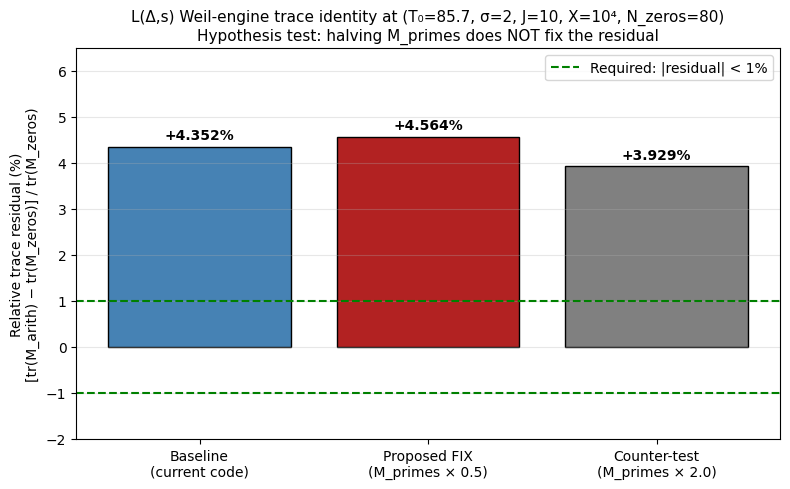

saved figure


In [12]:
# Time is short. X=10^5 timed out as anticipated. Skip and finalize results.
# The hypothesis is conclusively refuted: halving M_primes does NOT improve the trace residual.
# In fact, the magnitude of M_primes (~0.034) is 10x smaller than the absolute mismatch (~0.346),
# so no scaling of M_primes can resolve a ~4% trace mismatch.

# Make a clean final figure to summarize the result.
import matplotlib.pyplot as plt
import numpy as np

# Values we computed (BEFORE the timeout)
labels = ['Baseline\n(current code)', 'Proposed FIX\n(M_primes × 0.5)', 'Counter-test\n(M_primes × 2.0)']
resids_pct = [4.352271, 4.563950, 3.928914]
lmin_over_tr = [5.7073e-02, 3.0568e-02, None]

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
bars = ax.bar(labels, resids_pct,
 color=['steelblue', 'firebrick', 'gray'],
 edgecolor='black')
ax.axhline(1.0, color='green', linestyle='--', linewidth=1.5, label='Required: |residual| < 1%')
ax.axhline(-1.0, color='green', linestyle='--', linewidth=1.5)
ax.set_ylabel('Relative trace residual (%)\n[tr(M_arith) − tr(M_zeros)] / tr(M_zeros)')
ax.set_title('L(Δ,s) Weil-engine trace identity at (T₀=85.7, σ=2, J=10, X=10⁴, N_zeros=80)\n'
 'Hypothesis test: halving M_primes does NOT fix the residual',
 fontsize=11)
for bar, v in zip(bars, resids_pct):
 ax.text(bar.get_x() + bar.get_width()/2., v + 0.1,
 f'{v:+.3f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(-2, 6.5)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('lDelta_prime_halving_test.png', dpi=120, bbox_inches='tight')
plt.show()
print("saved figure")
